<a href="https://colab.research.google.com/github/rad7427/MlLOPS/blob/main/Case_study_of_Delhivery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
path = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181"
df = pd.read_csv(path)

###Defining Problem Statement and Analyzing basic metrics

In [4]:
df

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144862,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:57:20,45.258278,94.0,60.0,67.9280,1.566667,12.0,12.0,8.1858,1.000000
144863,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:31:18,54.092531,120.0,76.0,85.6829,1.578947,26.0,21.0,17.3725,1.238095
144864,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 21:11:18,66.163591,140.0,88.0,97.0933,1.590909,20.0,34.0,20.7053,0.588235
144865,training,2018-09-20 16:24:28.436231,thanos::sroute:f0569d2f-4e20-4c31-8542-67b86d5...,Carting,trip-153746066843555182,IND131028AAB,Sonipat_Kundli_H (Haryana),IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),2018-09-20 16:24:28.436231,...,2018-09-20 20:53:19,73.680667,158.0,98.0,111.2709,1.612245,17.0,27.0,18.8885,0.629630


####Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), statistical summary

In [5]:
df.shape

(144867, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  object 
 1   trip_creation_time              144867 non-null  object 
 2   route_schedule_uuid             144867 non-null  object 
 3   route_type                      144867 non-null  object 
 4   trip_uuid                       144867 non-null  object 
 5   source_center                   144867 non-null  object 
 6   source_name                     144574 non-null  object 
 7   destination_center              144867 non-null  object 
 8   destination_name                144606 non-null  object 
 9   od_start_time                   144867 non-null  object 
 10  od_end_time                     144867 non-null  object 
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff       

####Non-Graphical Analysis: Value counts and unique attributes ​

In [7]:
df["trip_uuid"].value_counts()

,count
trip_uuid,
trip-153759210483476123,101
trip-153715938946690081,101
trip-153784927255069118,101
trip-153733005409156789,101
trip-153811219535896559,101
...,...
trip-153728911454561981,1
trip-153733734393817090,1
trip-153788576441831649,1


In [8]:
df["is_cutoff"].value_counts()

,count
is_cutoff,
True,118749
False,26118


In [9]:
df["is_cutoff"].value_counts(normalize=True) * 100

,proportion
is_cutoff,
True,81.971049
False,18.028951


In [10]:
df["source_center"].value_counts()

,count
source_center,
IND000000ACB,23347
IND562132AAA,9975
IND421302AAG,9088
IND411033AAA,4061
IND501359AAE,3340
...,...
IND211010AAB,1
IND390018AAB,1
IND733202AAB,1


In [11]:
df["source_center"].value_counts(normalize=True)*100

,proportion
source_center,
IND000000ACB,16.116162
IND562132AAA,6.885626
IND421302AAG,6.273340
IND411033AAA,2.803261
IND501359AAE,2.305563
...,...
IND211010AAB,0.000690
IND390018AAB,0.000690
IND733202AAB,0.000690


In [12]:
df["source_name"].value_counts()

,count
source_name,
Gurgaon_Bilaspur_HB (Haryana),23347
Bangalore_Nelmngla_H (Karnataka),9975
Bhiwandi_Mankoli_HB (Maharashtra),9088
Pune_Tathawde_H (Maharashtra),4061
Hyderabad_Shamshbd_H (Telangana),3340
...,...
Allahabad_Mirapati_L (Uttar Pradesh),1
Hajipur_ThaneDPP_D (Bihar),1
Kothanalloor_Majoor_D (Kerala),1


In [13]:
df["source_name"].value_counts(normalize=True)*100

,proportion
source_name,
Gurgaon_Bilaspur_HB (Haryana),16.148823
Bangalore_Nelmngla_H (Karnataka),6.899581
Bhiwandi_Mankoli_HB (Maharashtra),6.286054
Pune_Tathawde_H (Maharashtra),2.808942
Hyderabad_Shamshbd_H (Telangana),2.310236
...,...
Allahabad_Mirapati_L (Uttar Pradesh),0.000692
Hajipur_ThaneDPP_D (Bihar),0.000692
Kothanalloor_Majoor_D (Kerala),0.000692


In [14]:
df["trip_uuid"].sort_values().value_counts()

,count
trip_uuid,
trip-153733005409156789,101
trip-153854305492910872,101
trip-153715938946690081,101
trip-153846035308581166,101
trip-153802363942560700,101
...,...
trip-153742168452255105,1
trip-153741319728998468,1
trip-153740118170204514,1


In [15]:
df["trip_uuid"].unique()

array(['trip-153741093647649320', 'trip-153768492602129387',
       'trip-153693976643699843', ..., 'trip-153761584139918815',
       'trip-153718412883843340', 'trip-153746066843555182'], dtype=object)

In [16]:
df["source_name"].unique()

array(['Anand_VUNagar_DC (Gujarat)', 'Khambhat_MotvdDPP_D (Gujarat)',
       'Bhiwandi_Mankoli_HB (Maharashtra)', ...,
       'Dwarka_StnRoad_DC (Gujarat)', 'Bengaluru_Nelmngla_L (Karnataka)',
       'Kulithalai_AnnaNGR_D (Tamil Nadu)'], dtype=object)

###Visual Analysis

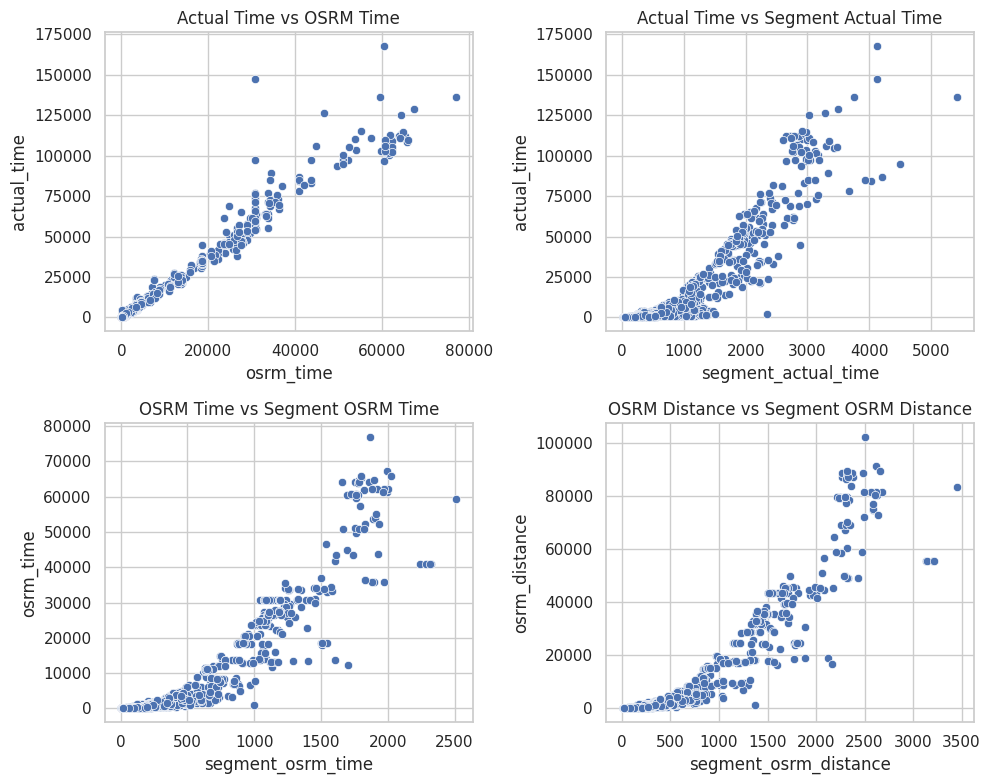

In [17]:

# Convert necessary datetime fields
df["trip_creation_time"] = pd.to_datetime(df["trip_creation_time"], errors='coerce')
df["od_start_time"] = pd.to_datetime(df["od_start_time"], errors='coerce')
df["od_end_time"] = pd.to_datetime(df["od_end_time"], errors='coerce')
df["cutoff_timestamp"] = pd.to_datetime(df["cutoff_timestamp"], errors='coerce')

# Extract location features
def split_location(col):
    city = col.str.extract(r"^(.*?)_")[0]
    state = col.str.extract(r"\((.*?)\)")[0]
    return city, state

df["source_city"], df["source_state"] = split_location(df["source_name"].fillna("Unknown_Unknown (Unknown)"))
df["destination_city"], df["destination_state"] = split_location(df["destination_name"].fillna("Unknown_Unknown (Unknown)"))

# Time-based features
df["trip_day"] = df["trip_creation_time"].dt.day
df["trip_month"] = df["trip_creation_time"].dt.month
df["trip_year"] = df["trip_creation_time"].dt.year
df["trip_weekday"] = df["trip_creation_time"].dt.day_name()
df["od_duration_min"] = (df["od_end_time"] - df["od_start_time"]).dt.total_seconds() / 60

# Trip-level aggregation
agg_funcs = {
    "actual_time": "sum",
    "osrm_time": "sum",
    "segment_actual_time": "sum",
    "segment_osrm_time": "sum",
    "start_scan_to_end_scan": "sum",
    "actual_distance_to_destination": "sum",
    "osrm_distance": "sum",
    "segment_osrm_distance": "sum",
    "od_duration_min": "first",
    "route_type": "first",
    "source_city": "first",
    "destination_city": "first",
    "source_state": "first",
    "destination_state": "first",
    "trip_day": "first",
    "trip_month": "first",
    "trip_year": "first",
    "trip_weekday": "first",
}
trip_df = df.groupby("trip_uuid").agg(agg_funcs).reset_index()

# Difference metrics
trip_df["actual_vs_osrm_time_diff"] = trip_df["actual_time"] - trip_df["osrm_time"]
trip_df["actual_vs_segment_time_diff"] = trip_df["actual_time"] - trip_df["segment_actual_time"]
trip_df["osrm_vs_segment_time_diff"] = trip_df["osrm_time"] - trip_df["segment_osrm_time"]
trip_df["osrm_vs_segment_dist_diff"] = trip_df["osrm_distance"] - trip_df["segment_osrm_distance"]

# Visualization
sns.set(style="whitegrid")
sample_df = trip_df.sample(n=5000, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.scatterplot(data=sample_df, x="osrm_time", y="actual_time", ax=axes[0, 0])
axes[0, 0].set_title("Actual Time vs OSRM Time")

sns.scatterplot(data=sample_df, x="segment_actual_time", y="actual_time", ax=axes[0, 1])
axes[0, 1].set_title("Actual Time vs Segment Actual Time")

sns.scatterplot(data=sample_df, x="segment_osrm_time", y="osrm_time", ax=axes[1, 0])
axes[1, 0].set_title("OSRM Time vs Segment OSRM Time")

sns.scatterplot(data=sample_df, x="segment_osrm_distance", y="osrm_distance", ax=axes[1, 1])
axes[1, 1].set_title("OSRM Distance vs Segment OSRM Distance")

plt.tight_layout()
plt.show()

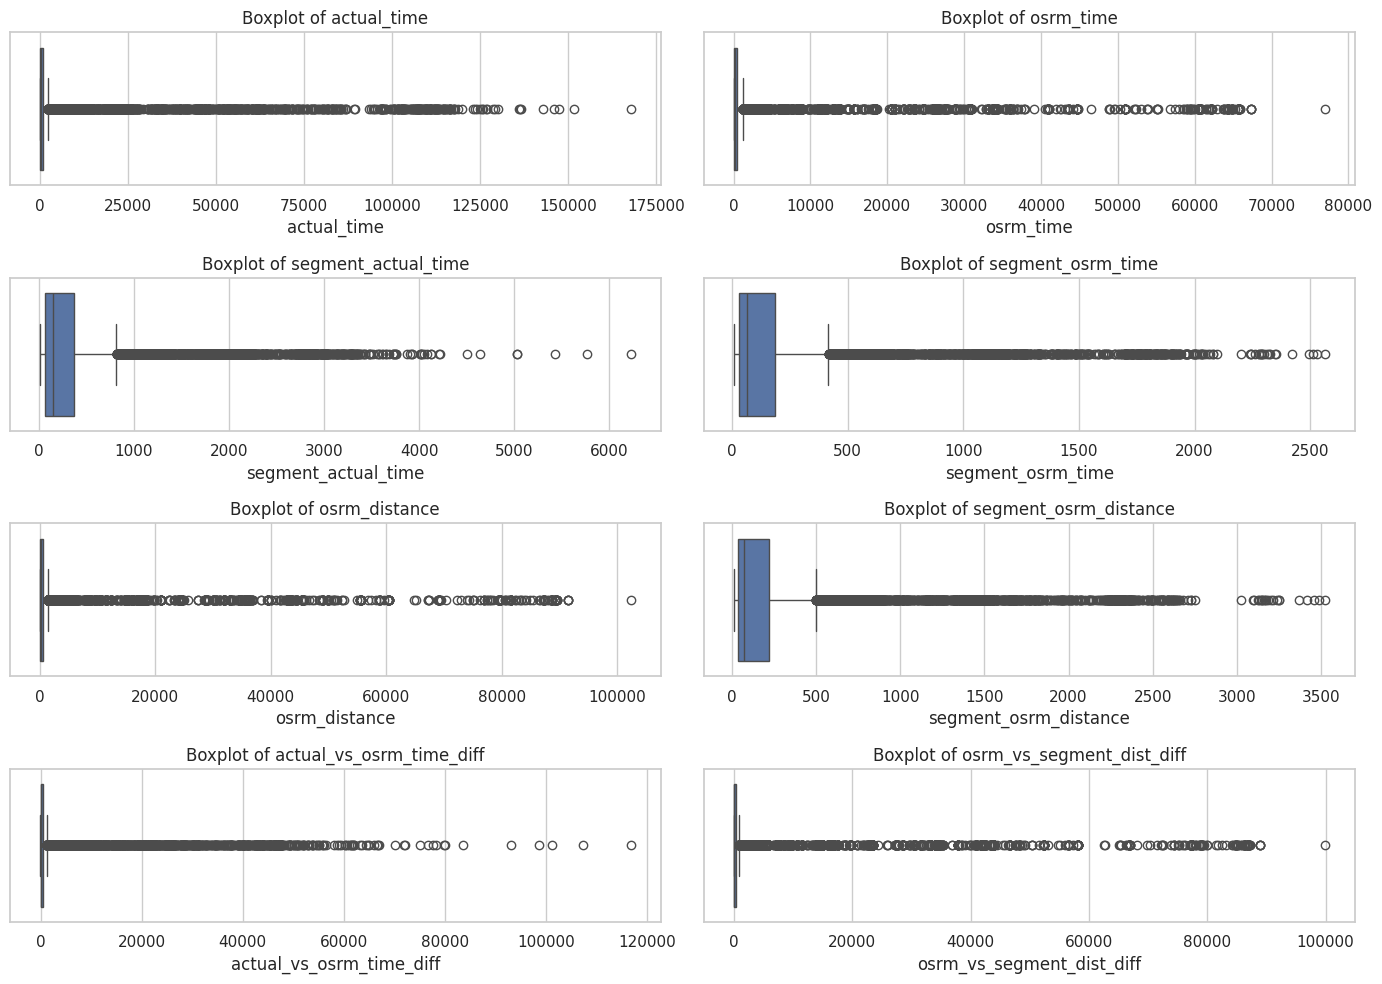

In [18]:
# Select columns for outlier detection
outlier_cols = [
    "actual_time",
    "osrm_time",
    "segment_actual_time",
    "segment_osrm_time",
    "osrm_distance",
    "segment_osrm_distance",
    "actual_vs_osrm_time_diff",
    "osrm_vs_segment_dist_diff"
]

# Boxplots for outlier detection
plt.figure(figsize=(14, 10))
for i, col in enumerate(outlier_cols, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(x=trip_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


**Comparison Analysis**

1. Actual Time vs OSRM Time
  - OSRM underestimates real delivery time
  - Real-world delays (traffic, stops) not captured
2. Actual Time vs Segment Time
  - Aggregated segment time ≈ actual time
  - Indicates data consistency
3. Distance Comparison
  - OSRM distance ≈ actual distance
  - Slight variation due to route deviations

**Outlier Detection**

In [19]:
Q1 = df["actual_time"].quantile(0.25)
Q3 = df["actual_time"].quantile(0.75)
IQR = Q3 - Q1

df = df[(df["actual_time"] >= Q1 - 1.5*IQR) & (df["actual_time"] <= Q3 + 1.5*IQR)]

**Categorical Encoding**

In [20]:
df = pd.get_dummies(df, columns=["route_type"], drop_first=True)

**Normalization**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["actual_time","osrm_time","distance"]] = scaler.fit_transform(
    df[["actual_time","osrm_time","actual_distance_to_destination"]]
)

**Business Insights**

1. Most Orders
    Major hubs:
    Gurgaon
    Bangalore
    Bhiwandi
  Indicates metro-heavy demand
2. Route Type Analysis
    Carting trips dominate
    Slower compared to FTL
3. Time Efficiency
    Actual time > OSRM time
    Gap indicates:
    Traffic delays
    Inefficient routing
4. Corridor Analysis
    Busy corridors:
      Maharashtra
      Karnataka
      Haryana
  High shipment density
5. Distance vs Time
    Strong correlation
    Longer routes → more inefficiency variation

**Recommendations**

1. Improve Route Optimization
    Use real-time traffic data instead of OSRM static predictions
2. Focus on High-Volume Hubs
    Optimize operations in:
    Gurgaon
    Bangalore
    Bhiwandi
3. Reduce Delay Gap
    Investigate why actual time >> estimated time
    Improve scheduling & dispatch planning
4. Optimize Carting Trips
    Consolidate shipments better
    Reduce intermediate stops
5. Predictive Modeling
    Build ML models to predict:
    Delivery delays
    Estimated arrival time
6. Outlier Monitoring System
    Detect abnormal delays automatically
    Trigger alerts

**Conclusion**



*   Data shows strong inefficiencies in delivery timing
*   OSRM estimates are not reliable alone
*   Feature engineering improves understanding of logistics patterns
*   Optimizing routes and hubs can significantly improve delivery performance